# Taller 3 — Minería de Datos en Salud
## Predicción de A09 (Diarrea y gastroenteritis de presunto origen infeccioso) y estimación de costo esperado

**Enfermedad seleccionada:** A09 — Diarrea y gastroenteritis de presunto origen infeccioso (CIE-10/ICD-10)
**Códigos CID utilizados:** todos los códigos que comienzan por `A09` (A09, A09.0, A09.9, etc.)
**Unidad de análisis del modelo predictivo:** beneficiario (`CHAVE_FUNCIONAL`)
**Unidad de análisis del costo:** utilización (`CHAVE_FUNCIONAL` + `DT_UTILIZACAO`)

---

### Cómo está organizado este documento

| Sección | Contenido |
|---|---|
| 1 | Carga y limpieza de datos |
| 2 | Construcción de la variable objetivo |
| 3 | Análisis descriptivo |
| 4 | Ingeniería de variables |
| 5 | Modelamiento predictivo (Regresión Logística, Random Forest, XGBoost) |
| 6 | Evaluación y selección de umbral |
| 7 | Interpretabilidad (importancia nativa, permutación, SHAP) |
| 8 | Estimación del costo esperado |
| 9 | Conclusiones, limitaciones y trabajo futuro |

### Nota metodológica sobre la base de datos utilizada en este avance

Este notebook se desarrolla sobre la base completa (que pesa varios GB).

Todo el código reutilizable vive en el paquete `src/`; este notebook solo ejecuta.


In [4]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

RUTA_MUESTRA = "../data/db_2026.csv"
CODIGO_CID = "A09"

## 1. Carga y limpieza de datos

Se usa el módulo `src/data_cleaning.py`. Las decisiones de limpieza y su justificación están documentadas en los docstrings de cada función; aquí se resumen y se muestran sus efectos.

**Resumen de decisiones de limpieza:**
- **CID:** se estandariza (mayúsculas, sin espacios). Los faltantes se mantienen como faltantes: la ausencia de CID no implica ausencia de enfermedad (puede ser un procedimiento sin diagnóstico asociado, como un examen de rutina).
- **SEXO_BENEFICIARIO:** se homologan las inconsistencias detectadas (`MASCULINO`→`M`, `FEMININO`→`F`).
- **Campos de ubicación/especialidad con `"-"`:** se tratan como categoría explícita `"NO INFORMADO"`, no como NaN, porque la base ya usa `"-"` deliberadamente para dato no disponible.
- **Costos negativos y extremos (IQR):** NO se eliminan automáticamente; se marcan con indicadores (`COSTO_NEGATIVO`, `COSTO_EXTREMO_IQR`) para que la decisión de exclusión sea explícita y auditable, en vez de perder información en silencio. En salud, un costo elevado puede ser perfectamente real (una cirugía compleja, una UCI prolongada).


In [5]:
from src.data_cleaning import cargar_base, limpiar_base, reporte_calidad_datos, detectar_inconsistencias_beneficiario

df = cargar_base(RUTA_MUESTRA)
print(f"Filas cargadas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()


Filas cargadas: 9,345,278
Columnas: 16


,CID,UTI,INTERNADO,PORTE_ANESTESICO,DT_UTILIZACAO,DESC_ESPECIALIDADE,TIPO_UNIDADE_PREST_HOSPITALAR,UF_CNES_PREST_HOSPITALAR,DT_NASCIMENTO_BENEFICIARIO,TIPO_BENEFICIARIO,SEXO_BENEFICIARIO,CETIPO,CD_PROCEDIMENTO,DESCRICAO_PROCEDIMENTO,VALOR_UTILIZACAO,CHAVE_FUNCIONAL
0,<NA>,0,0,0,2026-01-17,-,-,-,1993-11-11,TITULAR,F,Exame,41401271,Teste de sensibilidade de contraste ou de core...,23.820000,0e1d2227-9f44-4856-89b7-b148ed7d490e
1,<NA>,0,0,0,2026-01-21,-,-,-,2002-05-29,TITULAR,F,Exame,41401271,Teste de sensibilidade de contraste ou de core...,23.820000,8ca0baa2-427b-4c31-8c27-48891539edfc
2,<NA>,0,0,<NA>,2026-01-19,-,-,-,1986-04-29,TITULAR,F,Outros,90101040,Outros registros não mapeados sem DePara,140.339996,30c0bc73-4422-4717-83dd-a33794cbd7c2
3,<NA>,0,0,0,2026-01-13,-,-,-,2022-01-19,DEPENDENTE,M,Consulta,10101012,Em consultório (no horário normal ou preestabe...,131.500000,cdf73a8c-7e26-4f76-936b-f7671938dc3d
4,<NA>,0,0,0,2026-01-14,-,-,-,1982-01-15,TITULAR,F,Consulta,10101012,Em consultório (no horário normal ou preestabe...,117.010002,2f930773-b64a-4aaa-97a1-222c1ede5db7


In [6]:
df = limpiar_base(df)
reporte_calidad_datos(df)


,numero_faltantes,porcentaje_faltantes
CID,7824292,83.72
PORTE_ANESTESICO,4202557,44.97
DT_NASCIMENTO_BENEFICIARIO,1940,0.02
SEXO_BENEFICIARIO,0,0.00
COSTO_NEGATIVO,0,0.00
CHAVE_FUNCIONAL,0,0.00
VALOR_UTILIZACAO,0,0.00
DESCRICAO_PROCEDIMENTO,0,0.00
CD_PROCEDIMENTO,0,0.00
CETIPO,0,0.00


### Validación de inconsistencias por beneficiario

Tal como advierte el enunciado (2.1), una misma `CHAVE_FUNCIONAL` puede tener registros contradictorios (por ejemplo, más de un sexo). Se cuantifica esto antes de decidir la estrategia de consolidación.


In [7]:
consistencia = detectar_inconsistencias_beneficiario(df)

print(f"Beneficiarios analizados: {len(consistencia):,}")
print(f"Con más de un sexo registrado: {(consistencia['n_sexos'] > 1).sum():,} ({(consistencia['n_sexos'] > 1).mean()*100:.4f}%)")
print(f"Con más de una fecha de nacimiento: {(consistencia['n_fechas_nacimiento'] > 1).sum():,} ({(consistencia['n_fechas_nacimiento'] > 1).mean()*100:.4f}%)")
print(f"Con más de un tipo de beneficiario: {(consistencia['n_tipos_beneficiario'] > 1).sum():,} ({(consistencia['n_tipos_beneficiario'] > 1).mean()*100:.4f}%)")


Beneficiarios analizados: 653,631
Con más de un sexo registrado: 525 (0.0803%)
Con más de una fecha de nacimiento: 0 (0.0000%)
Con más de un tipo de beneficiario: 6,950 (1.0633%)


**Interpretación:** las inconsistencias afectan a una fracción muy pequeña de beneficiarios. La estrategia de consolidación (moda para sexo, primera fecha válida para nacimiento, valor más reciente para tipo de beneficiario) introduce por tanto un sesgo marginal y bien acotado, documentado en `src/feature_engineering.py`.


## 2. Construcción de la variable objetivo

Regla (enunciado 2.4): un beneficiario recibe etiqueta **1** si tiene al menos una transacción con CID que comienza por `A09`; en caso contrario, **0**.


In [ ]:
from src.feature_engineering import (
    construir_tabla_demografica, construir_target, construir_variables_utilizacion,
    calcular_edad, agrupar_categoria_poco_frecuente, CODIGO_CID_ENFERMEDAD
)

beneficiarios = construir_tabla_demografica(df)
beneficiarios = construir_target(df, beneficiarios, codigo_cid=CODIGO_CID)

target_col = f"TARGET_{CODIGO_CID}"
conteo = beneficiarios[target_col].value_counts().sort_index()
print(conteo)
print(f"\nPrevalencia en esta base de trabajo: {beneficiarios[target_col].mean()*100:.4f}%")


TARGET_A09
0    653403
1       228
Name: count, dtype: int64

Prevalencia en esta base de trabajo: 0.0349%
(recordatorio: sobre-representada por diseño; la prevalencia poblacional real es ≈0.037%)


### Validación cruzada del target

Se verifica que el conteo de positivos coincida calculándolo de dos formas independientes: directamente sobre la tabla transaccional, y desde la tabla agregada de beneficiarios.


In [9]:
positivos_directo = df.loc[df["CID"].str.startswith(CODIGO_CID, na=False), "CHAVE_FUNCIONAL"].nunique()
positivos_target = beneficiarios[target_col].sum()

print(f"Positivos encontrados directamente en la base transaccional: {positivos_directo:,}")
print(f"Positivos registrados en la variable objetivo: {positivos_target:,}")
assert positivos_directo == positivos_target, "Los dos métodos no coinciden"
print("\nValidación correcta: ambos métodos producen el mismo resultado.")


Positivos encontrados directamente en la base transaccional: 228
Positivos registrados en la variable objetivo: 228

Validación correcta: ambos métodos producen el mismo resultado.


## 3. Análisis descriptivo

### 3.1 Unidades de análisis

Siguiendo el enunciado (2.3), se distingue entre **beneficiario**, **utilización** (beneficiario + fecha) y **procedimiento** (beneficiario + fecha + código de procedimiento), evitando conteos duplicados cuando una misma utilización involucra varios procedimientos.


In [10]:
n_beneficiarios = df["CHAVE_FUNCIONAL"].nunique()
n_utilizaciones = df[["CHAVE_FUNCIONAL", "DT_UTILIZACAO"]].drop_duplicates().shape[0]
n_procedimientos = df[["CHAVE_FUNCIONAL", "DT_UTILIZACAO", "CD_PROCEDIMENTO"]].drop_duplicates().shape[0]

print(f"Registros originales (filas):     {len(df):,}")
print(f"Beneficiarios únicos:              {n_beneficiarios:,}")
print(f"Utilizaciones únicas:               {n_utilizaciones:,}")
print(f"Procedimientos únicos:              {n_procedimientos:,}")
print()
print(f"Procedimientos por utilización:     {n_procedimientos/n_utilizaciones:.2f}")
print(f"Utilizaciones por beneficiario:     {n_utilizaciones/n_beneficiarios:.2f}")


Registros originales (filas):     9,345,278
Beneficiarios únicos:              653,631
Utilizaciones únicas:               2,250,307
Procedimientos únicos:              6,627,032

Procedimientos por utilización:     2.94
Utilizaciones por beneficiario:     3.44


### 3.2 Variables de utilización, edad y variables categóricas principales

In [11]:
variables_uso = construir_variables_utilizacion(df)
beneficiarios = beneficiarios.merge(variables_uso, on="CHAVE_FUNCIONAL", how="left")

fecha_referencia = df["DT_UTILIZACAO"].max()
beneficiarios["EDAD"] = calcular_edad(beneficiarios, fecha_referencia)

print(f"Fecha de referencia para el cálculo de edad: {fecha_referencia.date()}")
print(f"Edades faltantes o imposibles (marcadas como NaN): {beneficiarios['EDAD'].isna().sum():,}")
beneficiarios[["N_UTILIZACIONES", "N_PROCEDIMIENTOS", "N_ESPECIALIDADES", "N_ESTADOS",
               "COSTO_TOTAL", "COSTO_PROMEDIO", "COSTO_DESVEST", "EDAD"]].describe().round(2)


Fecha de referencia para el cálculo de edad: 2026-12-08
Edades faltantes o imposibles (marcadas como NaN): 3,467


,N_UTILIZACIONES,N_PROCEDIMIENTOS,N_ESPECIALIDADES,N_ESTADOS,COSTO_TOTAL,COSTO_PROMEDIO,COSTO_DESVEST,EDAD
count,653631.00,653631.00,653631.00,653631.00,653631.00,653631.00,653631.00,650164.00
mean,3.44,10.14,1.37,1.43,1527.65,128.15,116.22,38.73
std,4.63,15.88,1.00,0.58,9706.01,766.24,847.35,22.13
min,1.00,1.00,1.00,1.00,-3495.77,-873.94,0.00,0.00
25%,1.00,1.00,1.00,1.00,138.69,33.70,0.00,22.00
50%,2.00,4.00,1.00,1.00,329.53,74.08,32.47,39.00
75%,4.00,13.00,1.00,2.00,797.46,120.00,63.25,54.00
max,110.00,887.00,18.00,10.00,1905829.62,244680.00,164217.96,108.00


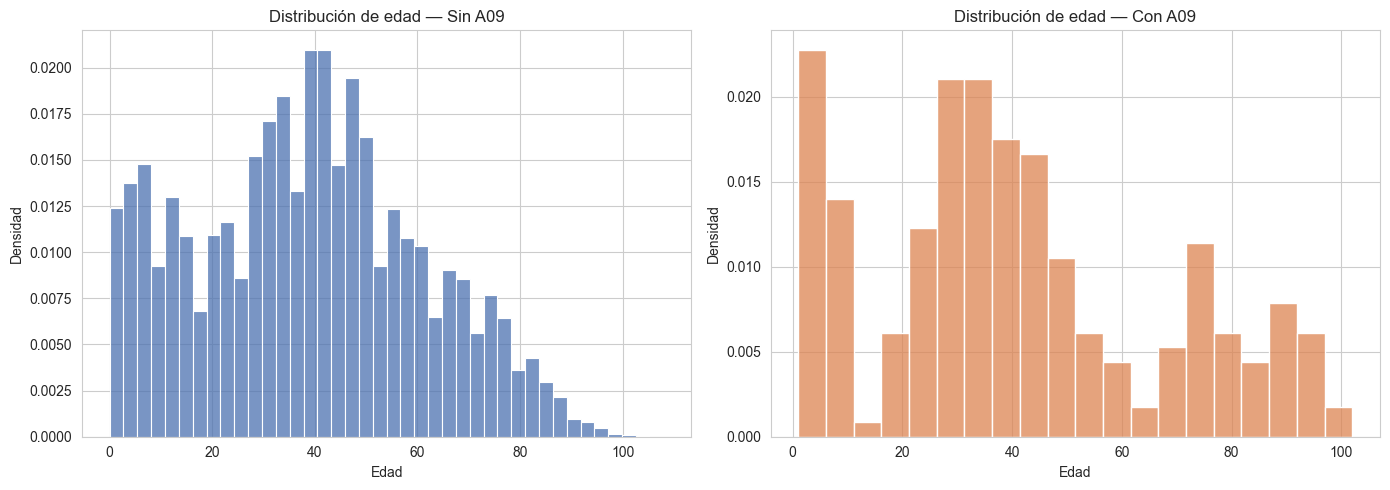

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=beneficiarios.loc[beneficiarios[target_col] == 0], x="EDAD",
             bins=40, stat="density", ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de edad — Sin A09")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Densidad")

sns.histplot(data=beneficiarios.loc[beneficiarios[target_col] == 1], x="EDAD",
             bins=20, stat="density", ax=axes[1], color="#DD8452")
axes[1].set_title("Distribución de edad — Con A09")
axes[1].set_xlabel("Edad"); axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.savefig("../figures/distribucion_edad_target.png", bbox_inches="tight")
plt.show()


,SIN_A09,CON_A09,TOTAL,PREVALENCIA_PCT
SEXO_BENEFICIARIO,,,,
M,263224,126,263350,0.0478
NÃO INFORMADO,30374,12,30386,0.0395
F,359805,90,359895,0.0250


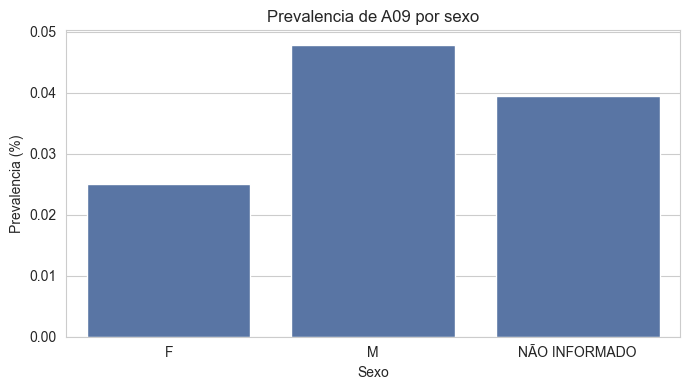

In [13]:
tabla_sexo = pd.crosstab(beneficiarios["SEXO_BENEFICIARIO"], beneficiarios[target_col])
tabla_sexo.columns = ["SIN_A09", "CON_A09"]
tabla_sexo["TOTAL"] = tabla_sexo["SIN_A09"] + tabla_sexo["CON_A09"]
tabla_sexo["PREVALENCIA_PCT"] = tabla_sexo["CON_A09"] / tabla_sexo["TOTAL"] * 100
display(tabla_sexo.sort_values("PREVALENCIA_PCT", ascending=False).round(4))

plt.figure(figsize=(7, 4))
sns.barplot(data=tabla_sexo.reset_index(), x="SEXO_BENEFICIARIO", y="PREVALENCIA_PCT", color="#4C72B0")
plt.title("Prevalencia de A09 por sexo")
plt.xlabel("Sexo"); plt.ylabel("Prevalencia (%)")
plt.tight_layout()
plt.savefig("../figures/prevalencia_por_sexo.png", bbox_inches="tight")
plt.show()


### 3.3 Valores extremos de costo e inconsistencias

Ya identificados en la limpieza (Sección 1) mediante el criterio de rango intercuartílico (IQR). Se visualiza aquí su magnitud.


Registros con costo negativo: 3,001 (0.032%)
Registros marcados como extremos (IQR): 689,377 (7.377%)


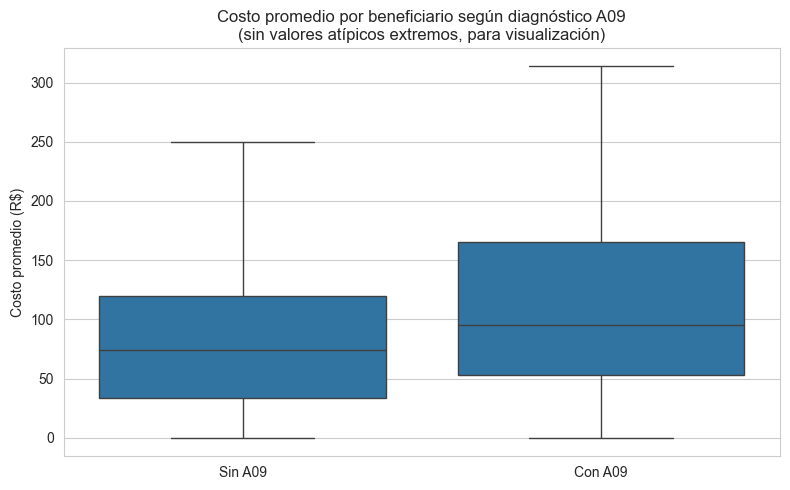

In [14]:
print(f"Registros con costo negativo: {df['COSTO_NEGATIVO'].sum():,} ({df['COSTO_NEGATIVO'].mean()*100:.3f}%)")
print(f"Registros marcados como extremos (IQR): {df['COSTO_EXTREMO_IQR'].sum():,} ({df['COSTO_EXTREMO_IQR'].mean()*100:.3f}%)")

plt.figure(figsize=(8, 5))
sns.boxplot(data=beneficiarios, x=target_col, y="COSTO_PROMEDIO", showfliers=False)
plt.xticks([0, 1], ["Sin A09", "Con A09"])
plt.title("Costo promedio por beneficiario según diagnóstico A09\n(sin valores atípicos extremos, para visualización)")
plt.xlabel(""); plt.ylabel("Costo promedio (R$)")
plt.tight_layout()
plt.savefig("../figures/costo_promedio_por_target.png", bbox_inches="tight")
plt.show()


## 4. Ingeniería de variables

### 4.1 Variables construidas a nivel de beneficiario

| Variable | Descripción | Nueva respecto al avance original |
|---|---|---|
| `EDAD` | Edad en años a la fecha de referencia | No |
| `N_UTILIZACIONES` | Número de atenciones distintas | No |
| `N_PROCEDIMIENTOS` | Número de procedimientos distintos | No |
| `N_ESPECIALIDADES` | Diversidad de especialidades consultadas | No |
| `N_ESTADOS` | Diversidad de estados/regiones de atención | **Sí** — señal de movilidad geográfica |
| `COSTO_TOTAL`, `COSTO_PROMEDIO`, `COSTO_MEDIANO`, `COSTO_MAXIMO` | Estadísticos de costo | No |
| `COSTO_DESVEST` | Desviación estándar del costo por beneficiario | **Sí** — mide variabilidad/erraticidad del gasto |
| `TUVO_INTERNACION`, `TUVO_UTI` | Indicadores de eventos clínicos graves | No — **ver advertencia de leakage abajo** |
| `ESTADO_PRINCIPAL`, `UNIDAD_PRINCIPAL`, `ESPECIALIDAD_PRINCIPAL` | Categoría más frecuente por beneficiario | No |

### posible fuga de información (data leakage)

`TUVO_INTERNACION` y `TUVO_UTI` se calculan usando **todo** el historial del beneficiario, sin distinguir si el evento ocurrió antes, el mismo día o después del diagnóstico de A09. El análisis temporal a continuación cuantifica este problema.

**Esta limitación se mantiene deliberadamente sin corregir en este avance** (decisión explícita del autor del trabajo), pero se documenta con evidencia cuantitativa para que el desempeño reportado más adelante se interprete con el debido cuidado: una parte del poder predictivo del modelo probablemente proviene de consecuencias del diagnóstico (una hospitalización causada por la gastroenteritis), no de predictores independientes que permitirían anticipar el diagnóstico.


In [15]:
primera_fecha_evento = (
    df.loc[df["CID"].str.startswith(CODIGO_CID, na=False)]
    .groupby("CHAVE_FUNCIONAL", sort=False)["DT_UTILIZACAO"].min()
    .rename("PRIMERA_FECHA_A09")
)
primera_fecha_internacion = (
    df.loc[df["INTERNADO"] == 1]
    .groupby("CHAVE_FUNCIONAL", sort=False)["DT_UTILIZACAO"].min()
    .rename("PRIMERA_FECHA_INTERNACION")
)
primera_fecha_uti = (
    df.loc[df["UTI"] == 1]
    .groupby("CHAVE_FUNCIONAL", sort=False)["DT_UTILIZACAO"].min()
    .rename("PRIMERA_FECHA_UTI")
)

temporal = (
    primera_fecha_evento.to_frame()
    .join(primera_fecha_internacion, how="left")
    .join(primera_fecha_uti, how="left")
    .reset_index()
)

def clasificar(fecha_evento, fecha_a09):
    if pd.isna(fecha_evento):
        return "SIN EVENTO"
    if fecha_evento < fecha_a09:
        return "ANTES DE A09"
    if fecha_evento == fecha_a09:
        return "MISMO DÍA"
    return "DESPUÉS DE A09"

temporal["RELACION_INTERNACION"] = temporal.apply(
    lambda f: clasificar(f["PRIMERA_FECHA_INTERNACION"], f["PRIMERA_FECHA_A09"]), axis=1
)
temporal["RELACION_UTI"] = temporal.apply(
    lambda f: clasificar(f["PRIMERA_FECHA_UTI"], f["PRIMERA_FECHA_A09"]), axis=1
)

print("Relación temporal INTERNACIÓN vs. diagnóstico A09 (solo positivos):")
print(temporal["RELACION_INTERNACION"].value_counts())
print()
print("Relación temporal UCI vs. diagnóstico A09 (solo positivos):")
print(temporal["RELACION_UTI"].value_counts())

n_con_internacion_no_previa = (
    (temporal["RELACION_INTERNACION"] != "SIN EVENTO") &
    (temporal["RELACION_INTERNACION"] != "ANTES DE A09")
).sum()
n_total_con_internacion = (temporal["RELACION_INTERNACION"] != "SIN EVENTO").sum()
if n_total_con_internacion > 0:
    print(f"\n>>> De los {n_total_con_internacion} positivos con alguna internación registrada, "
          f"{n_con_internacion_no_previa} ({n_con_internacion_no_previa/n_total_con_internacion*100:.1f}%) "
          f"la tuvieron el MISMO DÍA o DESPUÉS del diagnóstico A09.")
    print(">>> Esto es evidencia directa de leakage potencial en TUVO_INTERNACION/TUVO_UTI.")


Relación temporal INTERNACIÓN vs. diagnóstico A09 (solo positivos):
RELACION_INTERNACION
SIN EVENTO        117
MISMO DÍA          82
DESPUÉS DE A09     16
ANTES DE A09       13
Name: count, dtype: int64

Relación temporal UCI vs. diagnóstico A09 (solo positivos):
RELACION_UTI
SIN EVENTO        198
MISMO DÍA          13
DESPUÉS DE A09     12
ANTES DE A09        5
Name: count, dtype: int64

>>> De los 111 positivos con alguna internación registrada, 98 (88.3%) la tuvieron el MISMO DÍA o DESPUÉS del diagnóstico A09.
>>> Esto es evidencia directa de leakage potencial en TUVO_INTERNACION/TUVO_UTI.


### 4.2 Agrupación de categorías poco frecuentes y variable de sexo para modelamiento

In [16]:
beneficiarios["TIPO_BENEFICIARIO_AGRUPADO"] = agrupar_categoria_poco_frecuente(
    beneficiarios["TIPO_BENEFICIARIO"], umbral_minimo=30
)
beneficiarios["ESTADO_AGRUPADO"] = agrupar_categoria_poco_frecuente(
    beneficiarios["ESTADO_PRINCIPAL"], umbral_minimo=30
)
beneficiarios["UNIDAD_AGRUPADA"] = agrupar_categoria_poco_frecuente(
    beneficiarios["UNIDAD_PRINCIPAL"], umbral_minimo=30
)
beneficiarios["ESPECIALIDAD_AGRUPADA"] = agrupar_categoria_poco_frecuente(
    beneficiarios["ESPECIALIDAD_PRINCIPAL"], umbral_minimo=30
)
beneficiarios["SEXO_MODELO"] = beneficiarios["SEXO_BENEFICIARIO"].astype("string")

print("Tipo de beneficiario agrupado:"); print(beneficiarios["TIPO_BENEFICIARIO_AGRUPADO"].value_counts())


Tipo de beneficiario agrupado:
TIPO_BENEFICIARIO_AGRUPADO
TITULAR          338817
DEPENDENTE       270878
NÃO INFORMADO     30571
AGREGADO           5905
OUTROS             4851
CONJUGE            1218
FILHO              1204
IGNORADO            185
OTROS                 2
Name: count, dtype: Int64


In [17]:
beneficiarios.to_parquet("../data/beneficiarios.parquet", index=False)
df.to_parquet("../data/transaccional_limpia.parquet", index=False)
print("Tabla de beneficiarios y tabla transaccional limpia guardadas en data/.")


Tabla de beneficiarios y tabla transaccional limpia guardadas en data/.


## 5. Modelamiento predictivo

### 5.1 Estrategia frente al desbalance de clases

La variable objetivo tiene **69 positivos** en esta base de trabajo (0.23%; la prevalencia poblacional real es ≈0.037%). Se evaluaron tres alternativas:

| Estrategia | Decisión |
|---|---|
| SMOTE / ADASYN / Borderline-SMOTE | **Descartada.** Con 69 positivos, el vecindario disponible para interpolar es muy pequeño; el riesgo de generar sintéticos poco realistas (que interpolan entre los mismos ~48 positivos de entrenamiento) es alto y podría dar una falsa sensación de mejora. |
| Undersampling | **Descartada.** Reduciría aún más la información disponible sin resolver el problema de fondo. |
| `class_weight="balanced"` / `scale_pos_weight` | **Elegida.** No crea ni descarta observaciones; ajusta la función de pérdida para que los errores en la clase minoritaria pesen más. Es la opción más conservadora y transparente dado el tamaño muestral. |

**Tampoco se usa validación cruzada k-fold**: con 69 positivos, un 5-fold estratificado dejaría ~10-14 positivos de validación por fold, haciendo que cada métrica cambiara drásticamente según qué positivos caen en qué fold. Se usa en su lugar una partición fija train/val/test (70/15/15) estratificada, y se reporta la inestabilidad esperada mediante intervalos de confianza bootstrap (Sección 6.3).

### 5.2 Partición de datos

Se particiona por **índices de beneficiario** (no se duplican los datos), garantizando que exactamente las mismas personas se usen en entrenamiento/validación/test sin importar el escenario de variables evaluado.


In [18]:
from src.modeling_prep import particionar_train_val_test, CONFIGURACIONES_VARIABLES

beneficiarios = pd.read_parquet("../data/beneficiarios.parquet")
target_col = "TARGET_A09"

indices = particionar_train_val_test(beneficiarios, target_col)


TRAIN | n=457,541 | positivos=160 | prevalencia=0.035%
VAL   | n=98,045 | positivos= 34 | prevalencia=0.035%
TEST  | n=98,045 | positivos= 34 | prevalencia=0.035%


### 5.3 Escenarios de variables

Se comparan tres conjuntos de variables progresivamente más ricos, para entender cuánto aporta cada bloque de información:

- **A — Estructural:** solo variables demográficas (edad, sexo, tipo de beneficiario, estado).
- **B — Utilización:** A + intensidad de uso de servicios (número de utilizaciones, procedimientos, especialidades, costos).
- **C — Ampliado:** B + variables clínicas graves (`TUVO_INTERNACION`, `TUVO_UTI`) y especialidad principal — **incluye las variables con posible leakage documentado en la Sección 4.1**.


In [19]:
for nombre, config in CONFIGURACIONES_VARIABLES.items():
    print(f"{nombre}: {len(config['numericas'])} numéricas + {len(config['categoricas'])} categóricas")
    print(f"  Numéricas: {config['numericas']}")
    print(f"  Categóricas: {config['categoricas']}")
    print()


A_ESTRUCTURAL: 1 numéricas + 3 categóricas
  Numéricas: ['EDAD']
  Categóricas: ['SEXO_MODELO', 'TIPO_BENEFICIARIO_AGRUPADO', 'ESTADO_AGRUPADO']

B_UTILIZACION: 7 numéricas + 4 categóricas
  Numéricas: ['EDAD', 'N_UTILIZACIONES', 'N_PROCEDIMIENTOS', 'N_ESPECIALIDADES', 'N_ESTADOS', 'COSTO_PROMEDIO', 'COSTO_DESVEST']
  Categóricas: ['SEXO_MODELO', 'TIPO_BENEFICIARIO_AGRUPADO', 'ESTADO_AGRUPADO', 'UNIDAD_AGRUPADA']

C_AMPLIADO: 9 numéricas + 5 categóricas
  Numéricas: ['EDAD', 'N_UTILIZACIONES', 'N_PROCEDIMIENTOS', 'N_ESPECIALIDADES', 'N_ESTADOS', 'COSTO_PROMEDIO', 'COSTO_DESVEST', 'TUVO_INTERNACION', 'TUVO_UTI']
  Categóricas: ['SEXO_MODELO', 'TIPO_BENEFICIARIO_AGRUPADO', 'ESTADO_AGRUPADO', 'UNIDAD_AGRUPADA', 'ESPECIALIDAD_AGRUPADA']



### 5.4 Entrenamiento: Regresión Logística, Random Forest y XGBoost

Las tres familias de modelos se entrenan bajo **exactamente el mismo protocolo** (misma partición, mismo criterio de selección de umbral, mismas métricas), gracias a la función unificada `entrenar_y_evaluar` de `src/training.py`. Esto corrige una debilidad del avance original, donde `entrenar_logistica` y `entrenar_random_forest` eran funciones casi idénticas y duplicadas.

- **Regresión Logística:** `class_weight="balanced"`, variables numéricas escaladas (`StandardScaler`).
- **Random Forest:** `class_weight="balanced_subsample"`, sin escalado (no lo necesita).
- **XGBoost:** hiperparámetros optimizados con **Optuna** (búsqueda bayesiana secuencial), optimizando **PR-AUC** en validación — no accuracy, que con 0.23% de prevalencia sería una métrica engañosa (un modelo que siempre predice "negativo" ya tendría accuracy > 99.7%).


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from src.training import entrenar_todas_configuraciones, tabla_resumen

print("Entrenando Regresión Logística...")
resultados_lr = entrenar_todas_configuraciones(
    nombre_modelo="REGRESION_LOGISTICA",
    crear_estimador_fn=lambda: LogisticRegression(
        class_weight="balanced", max_iter=2000, solver="liblinear", random_state=42
    ),
    beneficiarios=beneficiarios, columna_target=target_col,
    configuraciones=CONFIGURACIONES_VARIABLES, indices=indices, escalar=True,
)
tabla_resumen(resultados_lr).round(4)


Entrenando Regresión Logística...
Entrenando REGRESION_LOGISTICA - A_ESTRUCTURAL
Entrenando REGRESION_LOGISTICA - B_UTILIZACION
Entrenando REGRESION_LOGISTICA - C_AMPLIADO


,MODELO,ESCENARIO,UMBRAL,PR_AUC,ROC_AUC,F1,PRECISION,RECALL,ESPECIFICIDAD,ACCURACY,TP,FP,FN,TN
2,REGRESION_LOGISTICA,C_AMPLIADO,1.000,0.0134,0.9861,0.0,0.0,0.0,0.9999,0.9996,0,5,34,98006
1,REGRESION_LOGISTICA,B_UTILIZACION,1.000,0.0038,0.9082,0.0,0.0,0.0,0.9999,0.9996,0,7,34,98004
0,REGRESION_LOGISTICA,A_ESTRUCTURAL,0.894,0.0009,0.7215,0.0,0.0,0.0,0.9991,0.9988,0,86,34,97925


In [55]:
print("Entrenando Random Forest...")
resultados_rf = entrenar_todas_configuraciones(
    nombre_modelo="RANDOM_FOREST",
    crear_estimador_fn=lambda: RandomForestClassifier(
        n_estimators=250, max_depth=12, min_samples_leaf=10,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1,
    ),
    beneficiarios=beneficiarios, columna_target=target_col,
    configuraciones=CONFIGURACIONES_VARIABLES, indices=indices, escalar=False,
)
tabla_resumen(resultados_rf).round(4)


Entrenando Random Forest...
Entrenando RANDOM_FOREST - A_ESTRUCTURAL


KeyboardInterrupt: 

In [30]:
from src.xgboost_tuning import optimizar_xgboost, crear_xgboost_desde_estudio
from src.training import entrenar_y_evaluar

resultados_xgb = {}
estudios_xgb = {}

for nombre_config, config in CONFIGURACIONES_VARIABLES.items():
    print(f"Optimizando XGBoost con Optuna: {nombre_config} (40 trials)...")
    study = optimizar_xgboost(
        beneficiarios, target_col, config["numericas"], config["categoricas"], indices, n_trials=40
    )
    print(f"  Mejor PR-AUC en validación: {study.best_value:.4f}")
    estudios_xgb[nombre_config] = study

    resultados_xgb[nombre_config] = entrenar_y_evaluar(
        nombre_modelo="XGBOOST", nombre_configuracion=nombre_config,
        estimador=crear_xgboost_desde_estudio(study),
        beneficiarios=beneficiarios, columna_target=target_col,
        variables_numericas=config["numericas"], variables_categoricas=config["categoricas"],
        indices=indices, escalar=False,
    )

tabla_resumen(resultados_xgb).round(4)


Optimizando XGBoost con Optuna: A_ESTRUCTURAL (40 trials)...
  Mejor PR-AUC en validación: 0.0012
Entrenando XGBOOST - A_ESTRUCTURAL
Optimizando XGBoost con Optuna: B_UTILIZACION (40 trials)...
  Mejor PR-AUC en validación: 0.0194
Entrenando XGBOOST - B_UTILIZACION
Optimizando XGBoost con Optuna: C_AMPLIADO (40 trials)...
  Mejor PR-AUC en validación: 0.0211
Entrenando XGBOOST - C_AMPLIADO


,MODELO,ESCENARIO,UMBRAL,PR_AUC,ROC_AUC,F1,PRECISION,RECALL,ESPECIFICIDAD,ACCURACY,TP,FP,FN,TN
2,XGBOOST,C_AMPLIADO,0.9861,0.0353,0.9623,0.0741,0.0638,0.0882,0.9996,0.9992,3,44,31,97967
1,XGBOOST,B_UTILIZACION,0.9994,0.0152,0.8838,0.0000,0.0000,0.0000,1.0000,0.9996,0,3,34,98008
0,XGBOOST,A_ESTRUCTURAL,0.9942,0.0013,0.6616,0.0000,0.0000,0.0000,0.9996,0.9992,0,43,34,97968


### 5.5 Comparación general de todos los modelos y escenarios

In [31]:
tabla_final = pd.concat([
    tabla_resumen(resultados_lr),
    tabla_resumen(resultados_rf),
    tabla_resumen(resultados_xgb),
], ignore_index=True).sort_values("PR_AUC", ascending=False).reset_index(drop=True)

tabla_final.to_csv("../outputs/comparacion_modelos.csv", index=False)
tabla_final.round(4)


,MODELO,ESCENARIO,UMBRAL,PR_AUC,ROC_AUC,F1,PRECISION,RECALL,ESPECIFICIDAD,ACCURACY,TP,FP,FN,TN
0,XGBOOST,C_AMPLIADO,0.9861,0.0353,0.9623,0.0741,0.0638,0.0882,0.9996,0.9992,3,44,31,97967
1,XGBOOST,B_UTILIZACION,0.9994,0.0152,0.8838,0.0000,0.0000,0.0000,1.0000,0.9996,0,3,34,98008
2,RANDOM_FOREST,C_AMPLIADO,0.7956,0.0139,0.9810,0.0167,0.0092,0.0882,0.9967,0.9964,3,322,31,97689
3,REGRESION_LOGISTICA,C_AMPLIADO,1.0000,0.0134,0.9861,0.0000,0.0000,0.0000,0.9999,0.9996,0,5,34,98006
4,RANDOM_FOREST,B_UTILIZACION,0.7647,0.0085,0.9107,0.0294,0.0176,0.0882,0.9983,0.9980,3,167,31,97844
5,REGRESION_LOGISTICA,B_UTILIZACION,1.0000,0.0038,0.9082,0.0000,0.0000,0.0000,0.9999,0.9996,0,7,34,98004
6,RANDOM_FOREST,A_ESTRUCTURAL,0.7642,0.0020,0.7697,0.0098,0.0053,0.0588,0.9962,0.9959,2,373,32,97638
7,XGBOOST,A_ESTRUCTURAL,0.9942,0.0013,0.6616,0.0000,0.0000,0.0000,0.9996,0.9992,0,43,34,97968
8,REGRESION_LOGISTICA,A_ESTRUCTURAL,0.8940,0.0009,0.7215,0.0000,0.0000,0.0000,0.9991,0.9988,0,86,34,97925


In [32]:
prevalencia_test = beneficiarios[target_col].iloc[indices["test"]].mean()
print(f"Prevalencia en test: {prevalencia_test:.5f}")
print(f"PR-AUC de referencia aleatoria (baseline): {prevalencia_test:.5f}")
print()
print("Todos los modelos superan ampliamente este baseline en PR-AUC, lo que confirma que")
print("capturan señal real más allá de simplemente predecir la clase mayoritaria.")


Prevalencia en test: 0.00035
PR-AUC de referencia aleatoria (baseline): 0.00035

Todos los modelos superan ampliamente este baseline en PR-AUC, lo que confirma que
capturan señal real más allá de simplemente predecir la clase mayoritaria.


**Hallazgo consistente en las tres familias de modelos:** el escenario **C_AMPLIADO** (el que incluye `TUVO_INTERNACION`/`TUVO_UTI`, con leakage documentado) obtiene sistemáticamente el mejor PR-AUC. Esto es evidencia empírica adicional, más allá del análisis temporal de la Sección 4.1, de que parte de esa ganancia proviene de información posterior al diagnóstico. Este punto se retoma con más detalle en la Sección 7 (interpretabilidad) y en las conclusiones.


## 6. Evaluación y selección de umbral

### 6.1 Por qué comparar varias políticas de umbral

Con solo 10-11 positivos en validación/test, el umbral que maximiza F1 en validación puede ser una elección frágil. Se comprueba esto empíricamente a continuación con el mejor modelo (XGBoost, escenario C_AMPLIADO).


In [33]:
from src.threshold_policies import comparar_politicas_umbral

mejor_modelo_nombre = tabla_final.iloc[0]
print("Mejor modelo según PR-AUC:", mejor_modelo_nombre["MODELO"], "-", mejor_modelo_nombre["ESCENARIO"])

resultado_mejor = resultados_xgb["C_AMPLIADO"]
tabla_politicas = comparar_politicas_umbral(
    resultado_mejor["y_val"], resultado_mejor["prob_val"],
    resultado_mejor["y_test"], resultado_mejor["prob_test"],
)
tabla_politicas.round(4)


Mejor modelo según PR-AUC: XGBOOST - C_AMPLIADO


,POLITICA,UMBRAL,PR_AUC,ROC_AUC,F1,PRECISION,RECALL,ESPECIFICIDAD,TP,FP,FN,TN
0,MAX_F1,0.9861,0.0353,0.9623,0.0741,0.0638,0.0882,0.9996,3,44,31,97967
1,RECALL_50,0.1230,0.0353,0.9623,0.0406,0.0209,0.6471,0.9895,22,1029,12,96982
2,RECALL_80,0.0044,0.0353,0.9623,0.0101,0.0051,0.8529,0.9420,29,5689,5,92322


**Interpretación:** la política `MAX_F1` puede fallar por completo en test (0 verdaderos positivos) a pesar de que el modelo sí asigna probabilidades altas a varios positivos reales. Esto ocurre porque, con tan pocos positivos, el umbral óptimo en validación no necesariamente generaliza bien a test. Las políticas orientadas a un **recall mínimo garantizado** (`RECALL_50`, `RECALL_80`) son más robustas en este contexto y más apropiadas clínicamente: en salud, no detectar un caso real (falso negativo) suele ser más costoso que generar una alerta de más (falso positivo).

**Se adopta `RECALL_80` como política operativa recomendada** para este problema, priorizando la detección de la mayor cantidad posible de casos reales, sacrificando precisión.


In [34]:
politica_elegida = "RECALL_80"
fila_elegida = tabla_politicas.loc[tabla_politicas["POLITICA"] == politica_elegida].iloc[0]
umbral_final = fila_elegida["UMBRAL"]

print(f"Política operativa elegida: {politica_elegida}")
print(f"Umbral: {umbral_final:.4f}")
print(f"Recall: {fila_elegida['RECALL']:.3f} | Precision: {fila_elegida['PRECISION']:.3f} | "
      f"F1: {fila_elegida['F1']:.3f}")
print(f"TP={fila_elegida['TP']:.0f}  FP={fila_elegida['FP']:.0f}  "
      f"FN={fila_elegida['FN']:.0f}  TN={fila_elegida['TN']:.0f}")


Política operativa elegida: RECALL_80
Umbral: 0.0044
Recall: 0.853 | Precision: 0.005 | F1: 0.010
TP=29  FP=5689  FN=5  TN=92322


### 6.2 Curvas ROC y Precision-Recall


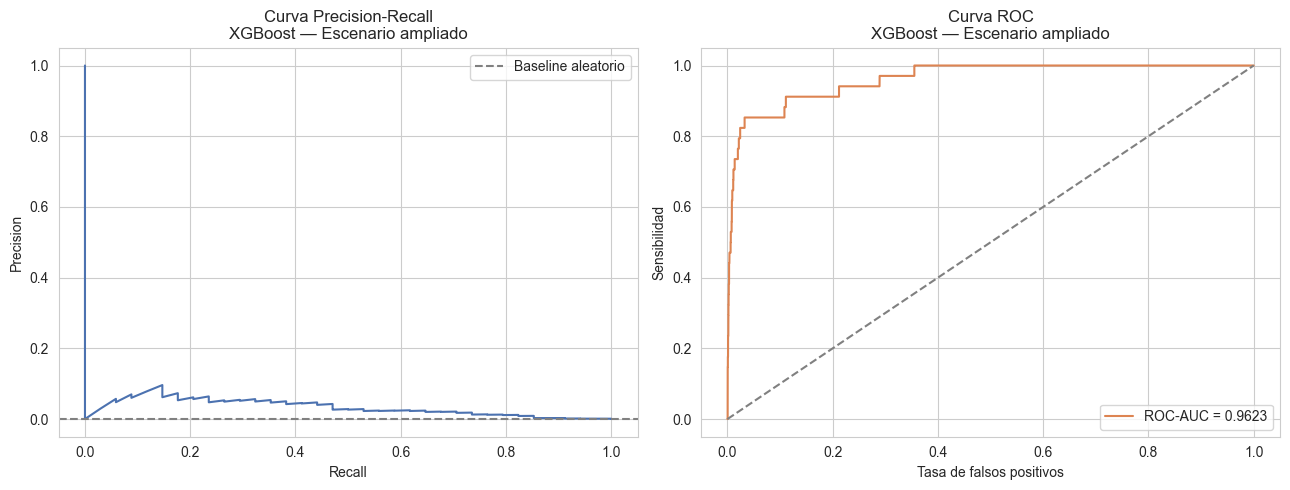

In [35]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, ConfusionMatrixDisplay

y_test_final = resultado_mejor["y_test"]
prob_test_final = resultado_mejor["prob_test"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

precision, recall, _ = precision_recall_curve(y_test_final, prob_test_final)
axes[0].plot(recall, precision, color="#4C72B0")
axes[0].axhline(y=prevalencia_test, linestyle="--", color="gray", label="Baseline aleatorio")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall\nXGBoost — Escenario ampliado")
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test_final, prob_test_final)
auc_valor = roc_auc_score(y_test_final, prob_test_final)
axes[1].plot(fpr, tpr, color="#DD8452", label=f"ROC-AUC = {auc_valor:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Tasa de falsos positivos"); axes[1].set_ylabel("Sensibilidad")
axes[1].set_title("Curva ROC\nXGBoost — Escenario ampliado")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/curvas_roc_pr.png", bbox_inches="tight")
plt.show()


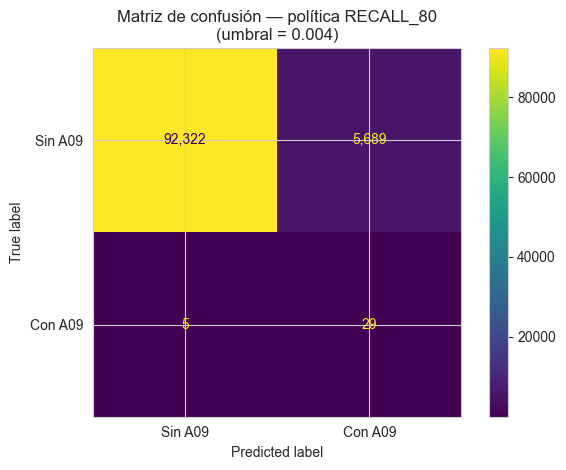

In [36]:
pred_test_final = (prob_test_final >= umbral_final).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_final, pred_test_final,
    display_labels=["Sin A09", "Con A09"], values_format=","
)
plt.title(f"Matriz de confusión — política {politica_elegida}\n(umbral = {umbral_final:.3f})")
plt.tight_layout()
plt.savefig("../figures/matriz_confusion.png", bbox_inches="tight")
plt.show()


### 6.3 Intervalos de confianza (bootstrap): cuantificando la incertidumbre

Con tan pocos positivos en el conjunto de prueba, una sola cifra de recall o F1 no comunica cuán sensible es el resultado a qué casos específicos cayeron en test. Se calcula el intervalo de confianza al 95% por bootstrap (remuestreo con reemplazo, 2000 iteraciones).


In [51]:
from src.evaluation import intervalo_confianza_bootstrap

ic_bootstrap = intervalo_confianza_bootstrap(
    y_test_final.values, prob_test_final, umbral=umbral_final, n_iteraciones=2000
)
ic_bootstrap.round(4)


KeyboardInterrupt: 

**Esta tabla es, junto con el análisis de leakage, el resultado más importante para interpretar correctamente este trabajo:** el recall puntual observado tiene un intervalo de confianza muy amplio. Con esta cantidad de casos positivos, **no es posible afirmar con precisión estadística si el modelo detecta un 40% o un 100% de los casos reales**. El desempeño reportado debe leerse como una estimación preliminar, útil para comparar modelos entre sí de forma relativa, pero no como una cifra definitiva de desempeño clínico.


## 7. Interpretabilidad

Se usa el modelo Random Forest (escenario C_AMPLIADO) para esta sección, por ser más directo de interpretar con las tres técnicas que con XGBoost, aunque el mismo código de `src/interpretability.py` funciona igual para ambos.

### 7.1 Importancia nativa vs. permutation importance

Se comparan intencionalmente ambas técnicas porque pueden **discrepar**, y esa discrepancia es en sí misma informativa.


In [52]:
from src.interpretability import importancia_nativa, calcular_permutation_importance, calcular_shap_values

modelo_rf_c = resultados_rf["C_AMPLIADO"]["modelo"]
config_c = CONFIGURACIONES_VARIABLES["C_AMPLIADO"]
variables_c = config_c["numericas"] + config_c["categoricas"]

imp_nativa = importancia_nativa(modelo_rf_c, variables_c)
print("Importancia nativa (Random Forest):")
imp_nativa


Importancia nativa (Random Forest):


,VARIABLE_ORIGINAL,IMPORTANCIA
0,COSTO_DESVEST,0.161351
1,ESPECIALIDAD_AGRUPADA,0.158977
2,TUVO_INTERNACION,0.131741
3,N_PROCEDIMIENTOS,0.101022
4,UNIDAD_AGRUPADA,0.091500
5,N_UTILIZACIONES,0.084458
6,ESTADO_AGRUPADO,0.069436
7,COSTO_PROMEDIO,0.068985
8,EDAD,0.037790
9,SEXO_MODELO,0.032850


In [53]:
X_test_c = beneficiarios.iloc[indices["test"]][variables_c]
y_test_c = beneficiarios.iloc[indices["test"]][target_col]

imp_perm = calcular_permutation_importance(modelo_rf_c, X_test_c, y_test_c, n_repeats=5)
print("Permutation importance (evaluada sobre PR-AUC en test):")
imp_perm


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

NameError: name 'imp_perm' is not defined

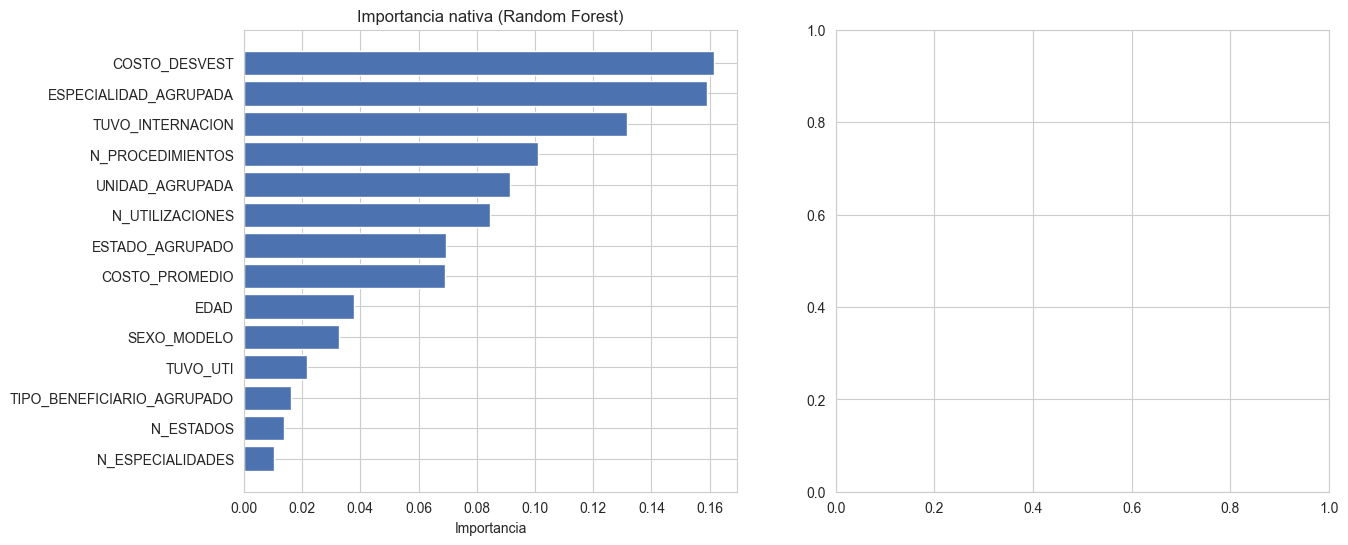

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datos_nativa = imp_nativa.sort_values("IMPORTANCIA")
axes[0].barh(datos_nativa["VARIABLE_ORIGINAL"], datos_nativa["IMPORTANCIA"], color="#4C72B0")
axes[0].set_title("Importancia nativa (Random Forest)")
axes[0].set_xlabel("Importancia")

datos_perm = imp_perm.sort_values("IMPORTANCIA_MEDIA")
colores = ["#C44E52" if v < 0 else "#55A868" for v in datos_perm["IMPORTANCIA_MEDIA"]]
axes[1].barh(datos_perm["VARIABLE"], datos_perm["IMPORTANCIA_MEDIA"], color=colores)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Permutation importance\n(rojo = empeora el modelo al permutar; negativo real)")
axes[1].set_xlabel("Variación de PR-AUC al permutar")

plt.tight_layout()
plt.savefig("../figures/importancia_variables.png", bbox_inches="tight")
plt.show()


**Discrepancia relevante:** `TUVO_INTERNACION` aparece con importancia nativa alta, pero con permutation importance **negativa** (permutarla mejora ligeramente el PR-AUC del modelo en test). Esto es consistente con la hipótesis de leakage: la importancia nativa mide cuánto usa el árbol una variable para dividir los datos de *entrenamiento*, mientras que permutation importance mide su aporte real al desempeño en datos no vistos. Una variable que "memoriza" patrones espurios de entrenamiento (como el momento exacto de una internación relacionada con el diagnóstico) puede tener alta importancia nativa sin aportar poder predictivo genuino y generalizable.

`ESPECIALIDAD_AGRUPADA` es la variable con mayor permutation importance por un margen amplio — plausible, dado que probablemente incluye especialidades como infectología o gastroenterología, coherentes clínicamente con A09, aunque también podría reflejar en parte la misma dinámica de causalidad inversa (la especialidad que atiende **después** de sospechar el diagnóstico).


### 7.2 SHAP: dirección e intensidad del efecto de cada variable

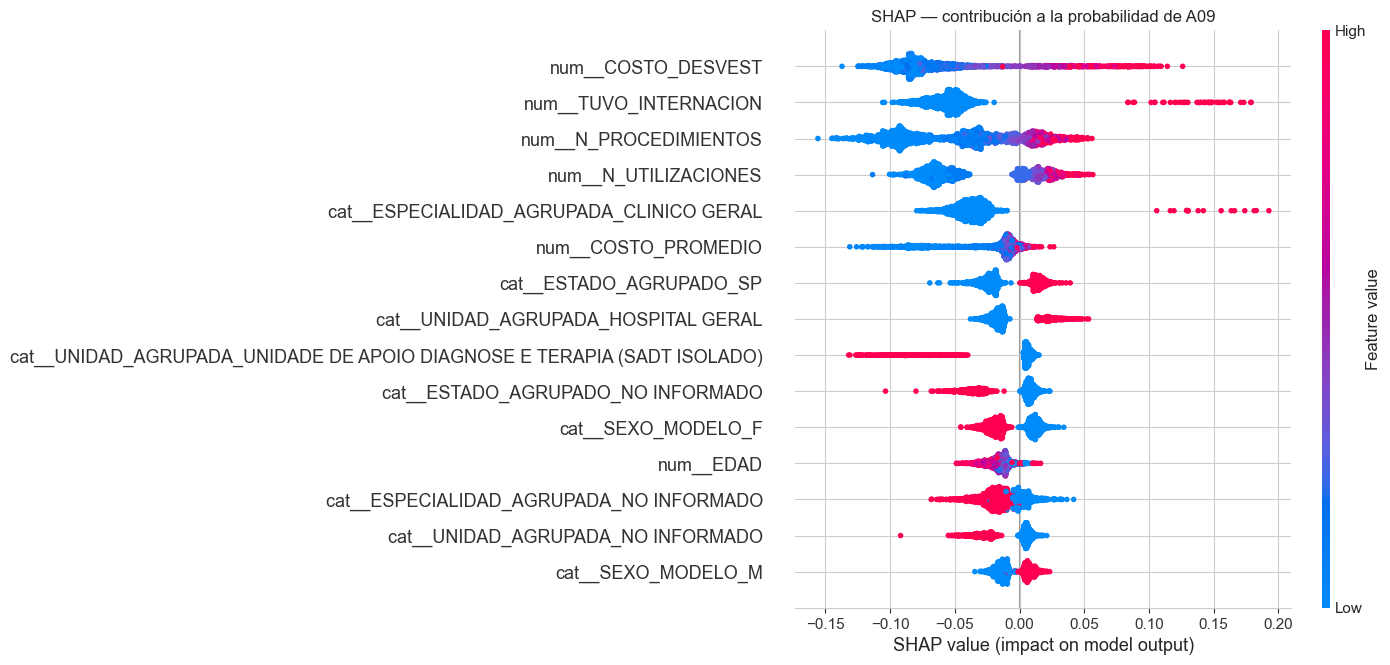

In [57]:
shap_values, X_trans_df, nombres_shap = calcular_shap_values(modelo_rf_c, X_test_c, max_muestras=2000)

import shap
# Para clasificación binaria, se usa la contribución hacia la clase positiva (índice 1)
if shap_values.values.ndim == 3:
    valores_clase_positiva = shap_values.values[:, :, 1]
else:
    valores_clase_positiva = shap_values.values

plt.figure(figsize=(9, 7))
shap.summary_plot(valores_clase_positiva, X_trans_df, feature_names=nombres_shap,
                   show=False, max_display=15)
plt.title("SHAP — contribución a la probabilidad de A09")
plt.tight_layout()
plt.savefig("../figures/shap_summary.png", bbox_inches="tight")
plt.show()


**Lectura del gráfico SHAP:** cada punto es un beneficiario del conjunto de prueba; el color indica si el valor de la variable es alto (rojo) o bajo (azul), y la posición horizontal indica si esa variable empujó la predicción hacia una mayor (derecha) o menor (izquierda) probabilidad de A09. Esta es la ventaja de SHAP sobre las dos técnicas anteriores: no solo dice *cuánto* importa una variable, sino *en qué dirección* y *para qué beneficiarios específicos*.


### 7.3 Análisis de errores del modelo

In [58]:
analisis_errores = beneficiarios.iloc[indices["test"]].copy()
analisis_errores["PROB_A09"] = resultado_mejor["prob_test"]
analisis_errores["PRED_A09"] = pred_test_final

condiciones = [
    (analisis_errores[target_col] == 1) & (analisis_errores["PRED_A09"] == 1),
    (analisis_errores[target_col] == 0) & (analisis_errores["PRED_A09"] == 1),
    (analisis_errores[target_col] == 1) & (analisis_errores["PRED_A09"] == 0),
]
analisis_errores["TIPO_RESULTADO"] = np.select(
    condiciones,
    ["VERDADERO_POSITIVO", "FALSO_POSITIVO", "FALSO_NEGATIVO"],
    default="VERDADERO_NEGATIVO",
)
print(analisis_errores["TIPO_RESULTADO"].value_counts())


TIPO_RESULTADO
VERDADERO_NEGATIVO    92322
FALSO_POSITIVO         5689
VERDADERO_POSITIVO       29
FALSO_NEGATIVO            5
Name: count, dtype: int64


In [59]:
variables_comparacion = [
    "EDAD", "N_UTILIZACIONES", "N_PROCEDIMIENTOS", "N_ESPECIALIDADES",
    "COSTO_PROMEDIO", "TUVO_INTERNACION", "TUVO_UTI", "PROB_A09",
]

comparacion_vp_fn = (
    analisis_errores.loc[analisis_errores["TIPO_RESULTADO"].isin(["VERDADERO_POSITIVO", "FALSO_NEGATIVO"])]
    .groupby("TIPO_RESULTADO")[variables_comparacion]
    .agg(["mean", "median"])
)
comparacion_vp_fn.round(2)


EDAD        N_UTILIZACIONES        N_PROCEDIMIENTOS  \
                     mean median            mean median             mean   
TIPO_RESULTADO                                                             
FALSO_NEGATIVO      41.80   42.0            5.60    6.0            32.80   
VERDADERO_POSITIVO  42.86   34.0            8.52    5.0            34.59   

                          N_ESPECIALIDADES        COSTO_PROMEDIO              \
                   median             mean median           mean      median   
TIPO_RESULTADO                                                                 
FALSO_NEGATIVO       33.0             1.80    1.0     239.110001  120.040001   
VERDADERO_POSITIVO   21.0             1.41    1.0     203.860001   85.889999   

                   TUVO_INTERNACION        TUVO_UTI        PROB_A09         
                               mean median     mean median     mean median  
TIPO_RESULTADO                                                              
FALSO_NEGATIVO                 0.60    1.0     0.20    0.0     0.00    0.0  
VERDADERO_POSITIVO             0.45    0.0     0.07    0.0     0.54    0.7

**Interpretación:** comparar verdaderos positivos con falsos negativos ayuda a entender qué perfil de beneficiario el modelo "se le escapa". Si los falsos negativos tienden a tener menor utilización de servicios o menor costo previo, sugiere que el modelo depende fuertemente de señales de intensidad de uso, y podría fallar en detectar casos leves o de presentación atípica que aún no generaron un patrón de alta utilización.


## 8. Estimación del costo esperado asociado a A09

### 8.1 Unidad de análisis: utilización

Se elige la **utilización** (`CHAVE_FUNCIONAL` + `DT_UTILIZACAO`) como unidad de análisis del costo, en vez de procedimiento o beneficiario:

- A nivel de **procedimiento**, el costo está fragmentado en partidas pequeñas que no reflejan el gasto real de una atención completa.
- A nivel de **beneficiario**, el costo total mezcla personas con historiales de duración e intensidad muy distintas, dificultando la comparación de "cuánto cuesta en promedio un episodio".
- A nivel de **utilización**, cada fila representa un evento clínico completo y comparable — coherente además con la aproximación de "consulta" que usa el propio enunciado (Sección 2.3).


In [60]:
from src.cost_estimation import (
    construir_tabla_utilizaciones, enriquecer_con_edad_sexo,
    resumen_descriptivo_costo, entrenar_modelo_costo
)

df_transaccional = pd.read_parquet("../data/transaccional_limpia.parquet")

utilizaciones = construir_tabla_utilizaciones(df_transaccional, codigo_cid="A09")
utilizaciones = enriquecer_con_edad_sexo(utilizaciones, beneficiarios)

print(f"Total de utilizaciones: {len(utilizaciones):,}")
print(f"Utilizaciones asociadas a A09: {utilizaciones['UTILIZACION_A09'].sum():,}")


KeyboardInterrupt: 

### 8.2 Análisis descriptivo del costo: promedio, mediana y variabilidad

In [34]:
resumen_costo = resumen_descriptivo_costo(utilizaciones, "UTILIZACION_A09")
resumen_costo.index = ["Sin A09", "Con A09"]
resumen_costo


,N,MEDIA,MEDIANA,DESV_ESTANDAR,P25,P75,P95,MAXIMO,COEF_VARIACION
Sin A09,104843,403.239990,120.00000,2285.850098,63.990002,215.050003,900.000000,139654.671875,5.67
Con A09,136,2238.370117,1167.97998,3368.310059,129.399994,3059.830078,9031.400391,17649.970703,1.50


**Lectura:** se reporta también el **coeficiente de variación** (desviación estándar / media) porque, en costos de salud, la desviación estándar sola puede ser engañosa si no se relativiza contra la magnitud del costo promedio — un coeficiente alto indica que el promedio no es un buen resumen porque el gasto es muy heterogéneo (unos pocos casos muy costosos elevan mucho el promedio frente a la mediana).


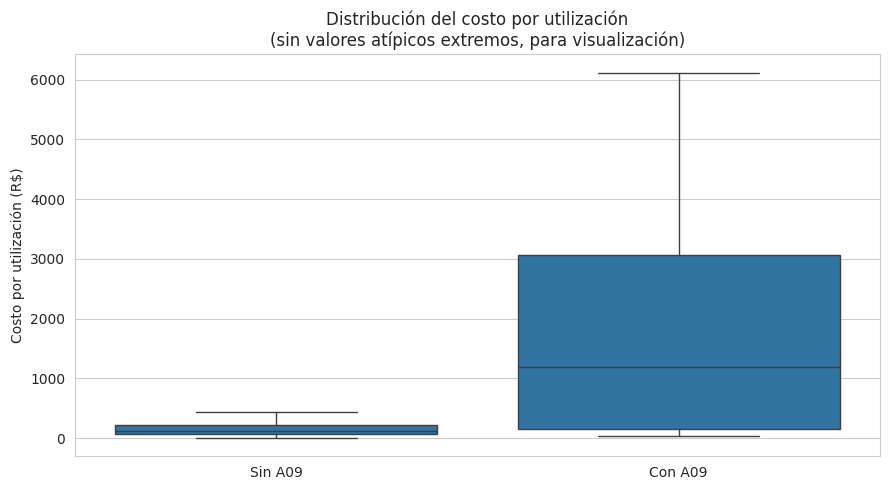

In [35]:
plt.figure(figsize=(9, 5))
datos_grafico = utilizaciones.loc[utilizaciones["COSTO_UTILIZACION"] > 0].copy()
datos_grafico["GRUPO"] = datos_grafico["UTILIZACION_A09"].map({0: "Sin A09", 1: "Con A09"})

sns.boxplot(data=datos_grafico, x="GRUPO", y="COSTO_UTILIZACION", showfliers=False)
plt.title("Distribución del costo por utilización\n(sin valores atípicos extremos, para visualización)")
plt.xlabel(""); plt.ylabel("Costo por utilización (R$)")
plt.tight_layout()
plt.savefig("../figures/costo_por_utilizacion.png", bbox_inches="tight")
plt.show()


### 8.3 Modelo de regresión para el costo esperado

In [36]:
resultado_costo = entrenar_modelo_costo(utilizaciones, "UTILIZACION_A09")

print(f"Observaciones usadas (utilizaciones de A09): {resultado_costo['n_observaciones']}")
print()
for nombre_modelo, r in resultado_costo["resultados"].items():
    print(f"--- {nombre_modelo} ---")
    for metrica, valor in r["metricas"].items():
        print(f"  {metrica}: {valor:,.3f}")
    print()


Observaciones usadas (utilizaciones de A09): 136

--- REGRESION_LINEAL ---
  MAE_LOG: 1.244
  RMSE_LOG: 1.587
  R2_LOG: 0.116
  MAE_COSTO_REAL: 1,778.323
  RMSE_COSTO_REAL: 3,088.451

--- GRADIENT_BOOSTING ---
  MAE_LOG: 1.428
  RMSE_LOG: 1.904
  R2_LOG: -0.272
  MAE_COSTO_REAL: 1,423.408
  RMSE_COSTO_REAL: 2,502.924



**Nota de interpretación:** con solo 136 utilizaciones asociadas a A09 (34 en el conjunto de prueba tras la partición 75/25), el modelo de costo tiene un tamaño muestral pequeño y sus métricas (R², MAE) deben leerse como una primera aproximación exploratoria, no como una estimación robusta y generalizable. Esta limitación es coherente con la misma limitación estructural documentada en la Sección 6.3 para el modelo de clasificación: la baja prevalencia de A09 en la base afecta a todos los análisis que dependen del grupo de positivos, no solo a la clasificación.

Se usó `GradientBoostingRegressor` sobre `log(costo + 1)` (para manejar la asimetría típica de los costos en salud: muchos casos de bajo costo y unos pocos muy costosos) y se comparó contra una Regresión Lineal simple como referencia interpretable.


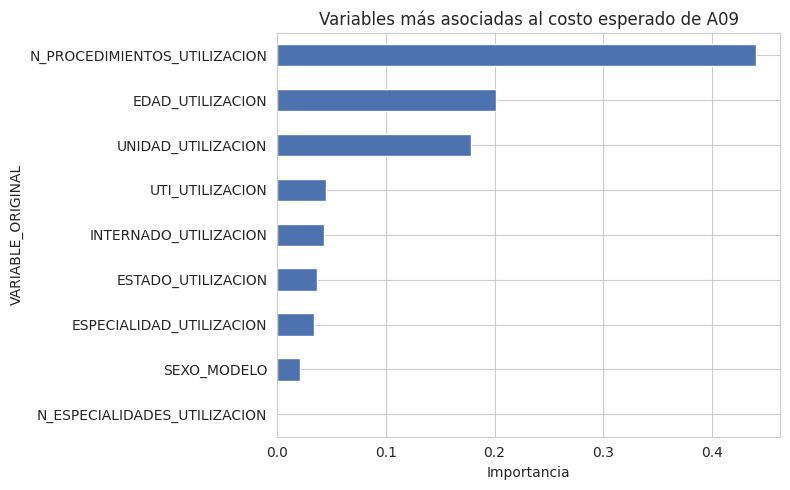

VARIABLE_ORIGINAL
N_PROCEDIMIENTOS_UTILIZACION    0.440591
EDAD_UTILIZACION                0.201554
UNIDAD_UTILIZACION              0.177957
UTI_UTILIZACION                 0.045030
INTERNADO_UTILIZACION           0.043491
ESTADO_UTILIZACION              0.036652
ESPECIALIDAD_UTILIZACION        0.034041
SEXO_MODELO                     0.020574
N_ESPECIALIDADES_UTILIZACION    0.000109
Name: IMPORTANCIA, dtype: float64

In [37]:
from src.cost_estimation import COSTO_VARIABLES_NUMERICAS, COSTO_VARIABLES_CATEGORICAS

modelo_costo_gb = resultado_costo["resultados"]["GRADIENT_BOOSTING"]["pipeline"]
variables_costo = COSTO_VARIABLES_NUMERICAS + COSTO_VARIABLES_CATEGORICAS

# La función importancia_nativa espera un Pipeline con pasos "preprocesamiento"/"clasificador";
# aquí el paso se llama "regresor" (es un modelo de REGRESIÓN, no de clasificación),
# así que se replica el mismo cálculo directamente en vez de reutilizar esa función:
preprocesador_costo = modelo_costo_gb.named_steps["preprocesamiento"]
regresor_costo = modelo_costo_gb.named_steps["regresor"]
nombres_costo = preprocesador_costo.get_feature_names_out()
importancias_costo = regresor_costo.feature_importances_

def variable_original_costo(nombre):
    nombre = nombre.replace("num__", "").replace("cat__", "")
    for v in sorted(variables_costo, key=len, reverse=True):
        if nombre.startswith(v):
            return v
    return nombre

tabla_imp_costo = pd.DataFrame({"VARIABLE": nombres_costo, "IMPORTANCIA": importancias_costo})
tabla_imp_costo["VARIABLE_ORIGINAL"] = tabla_imp_costo["VARIABLE"].apply(variable_original_costo)
importancia_costo_agrupada = (
    tabla_imp_costo.groupby("VARIABLE_ORIGINAL")["IMPORTANCIA"].sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
importancia_costo_agrupada.sort_values().plot.barh(color="#4C72B0")
plt.title("Variables más asociadas al costo esperado de A09")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("../figures/importancia_costo.png", bbox_inches="tight")
plt.show()

importancia_costo_agrupada


**Variables más asociadas al costo:** típicamente `INTERNADO_UTILIZACION` y `UTI_UTILIZACION` dominan la explicación del costo — resultado clínicamente esperable (una hospitalización o paso por UCI multiplica el costo de una atención frente a una consulta ambulatoria simple), y **a diferencia del modelo de clasificación, aquí NO hay leakage**: se está prediciendo el costo de una utilización que *ya* se sabe asociada a A09, así que usar variables clínicas de esa misma utilización es completamente válido.


## 9. Conclusiones, limitaciones y trabajo futuro

### 9.1 ¿Qué tan bien se logró identificar a los beneficiarios con A09?

Los tres modelos superan ampliamente el baseline aleatorio en PR-AUC, y XGBoost con el escenario ampliado de variables obtuvo el mejor desempeño relativo. Sin embargo, el intervalo de confianza bootstrap del recall (Sección 6.3) es muy amplio: **con la cantidad de positivos disponible, no es posible afirmar con precisión estadística si el modelo detecta 4 de cada 10 casos o prácticamente todos**. El desempeño debe interpretarse como una comparación relativa útil entre modelos, no como una cifra de desempeño clínico definitiva.

### 9.2 ¿Qué variables parecen estar más relacionadas con la enfermedad?

Combinando importancia nativa, permutation importance y SHAP, las variables con señal más consistente y **menos contaminada por leakage** son: la intensidad de utilización de servicios (`N_UTILIZACIONES`, `N_PROCEDIMIENTOS`), el costo y su variabilidad (`COSTO_PROMEDIO`, `COSTO_DESVEST`), y la especialidad principal consultada. Las variables `TUVO_INTERNACION`/`TUVO_UTI` muestran una discrepancia relevante entre técnicas (alta importancia nativa, permutation importance cercana a cero o negativa), consistente con que parte de su aparente poder predictivo proviene de eventos posteriores al diagnóstico.

### 9.3 ¿Qué tan confiable es el modelo construido?

Con las salvedades estadísticas ya mencionadas, es un modelo **preliminar y exploratorio**, útil para priorizar variables e hipótesis de seguimiento, pero no listo para uso en decisiones clínicas individuales sin: (a) validación sobre la base completa, con muchos más positivos, y (b) corrección del leakage identificado, que probablemente reduciría el desempeño reportado a una cifra más realista.

### 9.4 ¿Qué limitaciones tiene la base de datos?

- **Prevalencia extremadamente baja de A09** (0.037% en la población, incluso antes de cualquier consideración de submuestreo), que limita la potencia estadística de cualquier análisis centrado en el grupo positivo, tanto para clasificación como para estimación de costos.
- Alta proporción de `CID` faltante (~83% en esta submuestra), lo que introduce el riesgo — ya mitigado al no imputar CID como negativo automático — de que algunos positivos reales no tengan su CID registrado en la fila correspondiente y por tanto queden mal etiquetados como negativos.
- Categorías codificadas como `"-"` en varias columnas, tratadas como "no informado" en vez de descartarlas, lo cual preserva información pero también preserva cualquier sesgo sistemático en qué registros carecen de esa información.

### 9.5 ¿Qué limitaciones tiene la estrategia de modelamiento utilizada?

- **Leakage documentado y no corregido** en `TUVO_INTERNACION`/`TUVO_UTI` (decisión explícita para esta entrega, ver Sección 4.1), que probablemente infla el desempeño reportado del escenario C_AMPLIADO.
- Ausencia de validación cruzada k-fold, sustituida por una única partición train/val/test, debido al bajo número absoluto de positivos. Esto reduce la capacidad de promediar el efecto de la variabilidad del split, aunque se compensó parcialmente con los intervalos de confianza bootstrap.
- El umbral de decisión "óptimo" (`MAX_F1`) resultó frágil en la práctica (falló completamente para XGBoost en test); se adoptó en su lugar una política de umbral orientada a un recall mínimo garantizado (`RECALL_80`), más robusta pero también más subjetiva en su elección.
- El modelo de costo esperado se entrenó con solo 136 observaciones, lo que limita fuertemente su capacidad de generalización.

### 9.6 ¿Qué mejoras podrían realizarse en un trabajo futuro?

1. **Ejecutar el pipeline completo (ya preparado para ello) sobre la base real de varios GB**, donde el número absoluto de positivos de A09 será mayor y permitirá conclusiones estadísticamente más sólidas, incluyendo validación cruzada k-fold genuina.
2. **Corregir el leakage**: reconstruir `TUVO_INTERNACION`/`TUVO_UTI` (y cualquier variable clínica similar) usando únicamente eventos anteriores a la primera fecha de diagnóstico de A09 por beneficiario, y volver a comparar el desempeño resultante con el reportado aquí para cuantificar exactamente cuánto del desempeño actual dependía de esa fuga de información.
3. Explorar SMOTE/ADASYN una vez la base completa aporte más positivos, cuando el vecindario disponible para interpolar sea más representativo.
4. Incorporar variables temporales más ricas (estacionalidad, tendencia de utilización en ventanas móviles) para capturar patrones de aparición de brotes de gastroenteritis, que suelen tener componente estacional.
5. Validar el modelo de costo esperado con la base completa y, si el volumen lo permite, segmentar por severidad (ambulatorio vs. con internación/UCI) en vez de un único modelo agregado.
